In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.geometry import Geometry, get_rebinned_geometry
from analysis.utils.plot_utils import setup
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um, mm
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_root_path,
    get_parquet_path,
)

In [3]:
setup()

In [4]:
mosaix_geo = Geometry()

In [5]:
run = 10023
chunk = 0
path = get_root_path() / f"{run}/{run}_{chunk:03d}.root"

In [6]:
root_file = uproot.open(path)
geom = root_file["geometry"].arrays(library="np")

In [9]:
geo = create_geometry_from_root(path, num_scintillators=0)

31.01


In [31]:
geom["scint_bar_flag"]

array([1.e-45], dtype=float32)

In [32]:
geom["sim_flag"]

array([1.e-45], dtype=float32)

In [21]:
geom["scint_bar_flag"]

array([1.e-45], dtype=float32)

In [40]:
geo = create_geometry_from_root(path)

In [41]:
geo.layer_thickness

np.float32(13.01)

In [27]:
geo.layer_thickness - geo.tungsten_thickness - geo.silicon_thickness

np.float32(5.0)

In [50]:
geo.detector_x_size

np.float64(265.9904)

In [46]:
geo.layer_thickness

np.float32(10.01)

In [44]:
geom["scint_bar_flag"]

array([1.e-45], dtype=float32)

In [42]:
geom.keys()

dict_keys(['detector_width', 'detector_height', 'tungsten_thickness', 'silicon_thickness', 'nLayers', 'pixel_Xpos', 'pixel_Ypos', 'pixel_Zpos', 'sim_flag', 'scint_bar_flag'])

In [40]:
geom["nLayers"]

array([149], dtype=int32)

In [32]:
create_geometry_from_root(path)

0.020800000000000003


Geometry(pixel_x_size=np.float64(2.0800000000000004e-05), pixel_y_size=0.0228, num_x_pixels=12788, num_y_pixels=8596, num_layers=150, tungsten_thickness=5.0, silicon_thickness=0.01, box_thickness=5.0, scintillator_thickness=5.0, num_scintillator_layers=0, z_offset=0)

In [27]:
geom["sim_flag"]

array([nan], dtype=float32)

In [28]:
geom["scint_bar_flag"]

array([1.e-45], dtype=float32)

In [19]:
geom.keys()

dict_keys(['detector_width', 'detector_height', 'tungsten_thickness', 'silicon_thickness', 'nLayers', 'pixel_Xpos', 'pixel_Ypos', 'pixel_Zpos', 'sim_flag', 'scint_bar_flag'])

In [4]:
run = 10000
chunk = 0
df = pd.read_parquet(get_parquet_path() / f"{run}/{run}_{chunk}_hits.parq")
truth_df = pd.read_parquet(get_parquet_path() / f"{run}/{run}_{chunk}_truth.parq")

In [5]:
df.head()

event_id  hit_rowID  hit_colID  hit_layerID    hit_pdgc  \
entry subentry                                                            
0     0                0       4370        522            4  4294967085   
      1                0       4363        501            5  4294967085   
      2                0       4354        485            6  4294967085   
      3                0       4340        469            7  4294967085   
      4                0       4321        455            8  4294967085   

                hit_edep         x       y       z  
entry subentry                                      
0     0         0.002748 -122.1320  1.6474  50.045  
      1         0.006276 -122.5688  1.4878  60.055  
      2         0.003874 -122.9016  1.2826  70.065  
      3         0.004552 -123.2344  0.9634  80.075  
      4         0.004467 -123.5256  0.5302  90.085

In [8]:
event_id = 0
event_df = df.query("event_id == @event_id")


In [6]:
df["hit_pdgc"].value_counts()

hit_pdgc
11            18610986
4294967285     9612835
4294967085      501554
211             488679
2212            356160
321              37791
4294966975       19686
1000010020       10543
4294965084        6581
4294967283        6293
13                2607
1000140280        1420
1000010030        1380
3112              1048
3222               539
4294964184         325
1000020040         238
1000020030         215
4294964074         106
1000140290          85
1000140300          58
4294963984          56
3334                55
411                 52
431                 45
1000130270          40
4294966885          36
1000070140          36
1000120260          21
3312                21
1000020060          17
1000030060          16
1000120240          13
1000080160          12
1000120250          11
4294966865           8
1000130280           8
1000030070           7
1000130260           5
1000140270           3
1000100200           3
1000110230           2
1000060120           2
10

In [30]:
df

event_id  hit_rowID  hit_colID  hit_layerID    hit_pdgc  \
entry subentry                                                            
0     0                0       4370        522            4  4294967085   
      1                0       4363        501            5  4294967085   
      2                0       4354        485            6  4294967085   
      3                0       4340        469            7  4294967085   
      4                0       4321        455            8  4294967085   
...                  ...        ...        ...          ...         ...   
999   24672          999       5772       4394            5          11   
      24673          999       5723       4457            5          11   
      24674          999       5740       4449            5          11   
      24675          999       6179       3889            5          11   
      24676          999       5724       4025            5          11   

                hit_edep         x        y       z  
entry subentry                                       
0     0         0.002748 -122.1320   1.6474  50.045  
      1         0.006276 -122.5688   1.4878  60.055  
      2         0.003874 -122.9016   1.2826  70.065  
      3         0.004552 -123.2344   0.9634  80.075  
      4         0.004467 -123.5256   0.5302  90.085  
...                  ...       ...      ...     ...  
999   24672     0.002585  -41.5944  33.6130  60.055  
      24673     0.110265  -40.2840  32.4958  60.055  
      24674     0.001136  -40.4504  32.8834  60.055  
      24675     0.001285  -52.0984  42.8926  60.055  
      24676     0.005879  -49.2696  32.5186  60.055  

[29659615 rows x 9 columns]

In [29]:
df["hit_pdgc"].value_counts()

hit_pdgc
11            18610986
4294967285     9612835
4294967085      501554
211             488679
2212            356160
321              37791
4294966975       19686
1000010020       10543
4294965084        6581
4294967283        6293
13                2607
1000140280        1420
1000010030        1380
3112              1048
3222               539
4294964184         325
1000020040         238
1000020030         215
4294964074         106
1000140290          85
1000140300          58
4294963984          56
3334                55
411                 52
431                 45
1000130270          40
4294966885          36
1000070140          36
1000120260          21
3312                21
1000020060          17
1000030060          16
1000120240          13
1000080160          12
1000120250          11
4294966865           8
1000130280           8
1000030070           7
1000130260           5
1000140270           3
1000100200           3
1000110230           2
1000060120           2
10

In [ ]:
rebinned_df = pd.read_parquet(
    get_parquet_path() / f"{run}/200um_bins/{run}_{chunk}_hits.parq"
)

In [27]:
rebinned_df

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits
0,0,0,359,520,0.002302,1
1,0,0,388,503,0.004190,1
2,0,3,33,646,0.004992,1
3,0,3,56,671,0.003219,1
4,0,3,63,488,0.046166,1
...,...,...,...,...,...,...
21389829,999,113,85,754,0.004209,1
21389830,999,113,580,464,0.049417,1
21389831,999,114,48,791,0.001721,1
21389832,999,115,12,831,0.004842,1


In [17]:
nhits, counts = np.unique(rebinned_df["n_hits"], return_counts=True)

In [25]:
nhits_edges = np.hstack([0.5, nhits + 0.5])

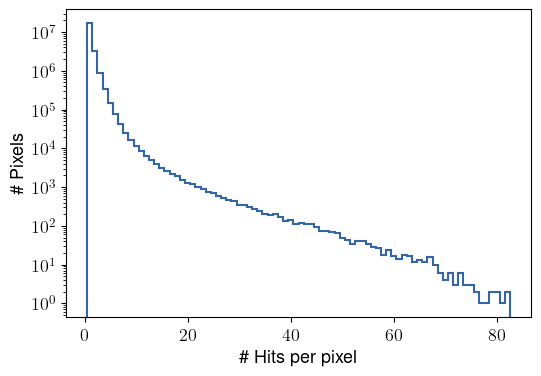

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
mplhep.histplot(H=counts, bins=nhits_edges)
ax.set_yscale("log")
ax.set_xlabel(r"\# Hits per pixel")
ax.set_ylabel(r"\# Pixels")
plt.show()

In [8]:
df.head()

event_id  hit_rowID  hit_colID  hit_layerID    hit_pdgc  \
entry subentry                                                            
0     0                0       4370        522            4  4294967085   
      1                0       4363        501            5  4294967085   
      2                0       4354        485            6  4294967085   
      3                0       4340        469            7  4294967085   
      4                0       4321        455            8  4294967085   

                hit_edep         x       y       z  
entry subentry                                      
0     0         0.002748 -122.1320  1.6474  50.045  
      1         0.006276 -122.5688  1.4878  60.055  
      2         0.003874 -122.9016  1.2826  70.065  
      3         0.004552 -123.2344  0.9634  80.075  
      4         0.004467 -123.5256  0.5302  90.085

In [ ]:
df[""]

In [60]:
def plot_hits(
    df: pd.DataFrame,
    xvar: str,
    yvar: str,
    xlabel: str,
    ylabel: str,
    nxbins: int,
    nybins: int,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    weight: str | float = 1.0,
    ax: plt.Axes | None = None,
):
    if ax is None:
        fig, _ax = plt.subplots(figsize=(6, 4))
    else:
        _ax = ax
    if isinstance(weight, str):
        _weight = df[weight]
    else:
        _weight = weight

    h = hist.Hist(
        hist.axis.Regular(nxbins, xlim[0], xlim[1]),
        hist.axis.Regular(nybins, ylim[0], ylim[1]),
        storage=hist.storage.Weight(),
    )
    h.fill(df[xvar], df[yvar], weight=_weight)

    mplhep.hist2dplot(
        h, cmap="viridis", norm=mpl.colors.LogNorm(), cbar=False, ax=_ax, flow=False
    )
    _ax.set_xlabel(xlabel)
    _ax.set_ylabel(ylabel)
    plt.show()


def plot_zx_hist(
    df: pd.DataFrame,
    truth: TruthParticle,
    geo: Geometry,
    range: float | None = None,
    xvar: str = "z",
    yvar: str = "x",
    xlabel: str = r"$z$ [mm]",
    ylabel: str = r"$x$ [mm]",
):
    xlim = (geo.zmin, geo.zmax)
    if range is None:
        ylim = (geo.xmin, geo.xmax)
    else:
        ylim = (truth.x - range, truth.x + range)
    # nxbins = int((xlim[1] - xlim[0]) // geo.num_layers)
    nxbins = geo.num_layers
    ny_bins = int((ylim[1] - ylim[0]) // geo.pixel_x_size)
    print(xlim, nxbins, geo.num_layers)
    print(ylim, ny_bins, geo.pixel_x_size)
    return plot_hits(
        df=df,
        xvar=xvar,
        yvar=yvar,
        xlabel=xlabel,
        ylabel=ylabel,
        nxbins=nxbins,
        nybins=ny_bins,
        xlim=xlim,
        ylim=ylim,
    )

In [ ]:
def scatter_hits(
    df: pd.DataFrame,
    xvar: str,
    yvar: str,
    xlabel: str,
    ylabel: str,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    ax: plt.Axes | None = None,
    **kwargs,
) -> None:
    if ax is None:
        fig, _ax = plt.subplots(figsize=(6, 4))
    else:
        _ax = ax

    plot_dict = {"color": "black", "size": 1}
    plot_dict.update(kwargs)
    ax.scatter(df[xvar], df[yvar], s=plot_dict["size"], c=plot_dict["color"])

    _ax.set_xlabel(xlabel)
    _ax.set_ylabel(ylabel)
    _ax.set_xlim(xlim)
    _ax.set_ylim(ylim)
    plt.show()


def scatter_zx_hits(
    df: pd.DataFrame,
    truth: TruthParticle,
    geo: Geometry,
    range: float | None = None,
    xvar: str = "z",
    yvar: str = "x",
    xlabel: str = r"$z$ [mm]",
    ylabel: str = r"$x$ [mm]",
) -> None:
    pass


def plot_zx_hist(
    df: pd.DataFrame,
    truth: TruthParticle,
    geo: Geometry,
    range: float | None = None,
    xvar: str = "z",
    yvar: str = "x",
    xlabel: str = r"$z$ [mm]",
    ylabel: str = r"$x$ [mm]",
):
    xlim = (geo.zmin, geo.zmax)
    if range is None:
        ylim = (geo.xmin, geo.xmax)
    else:
        ylim = (truth.x - range, truth.x + range)
    # nxbins = int((xlim[1] - xlim[0]) // geo.num_layers)
    nxbins = geo.num_layers
    ny_bins = int((ylim[1] - ylim[0]) // geo.pixel_x_size)
    print(xlim, nxbins, geo.num_layers)
    print(ylim, ny_bins, geo.pixel_x_size)
    return plot_hits(
        df=df,
        xvar=xvar,
        yvar=yvar,
        xlabel=xlabel,
        ylabel=ylabel,
        nxbins=nxbins,
        nybins=ny_bins,
        xlim=xlim,
        ylim=ylim,
    )

(0, 1501.5) 150 150
(np.float64(-131.72957984768132), np.float64(-111.72957984768132)) 961 0.020800000000000003


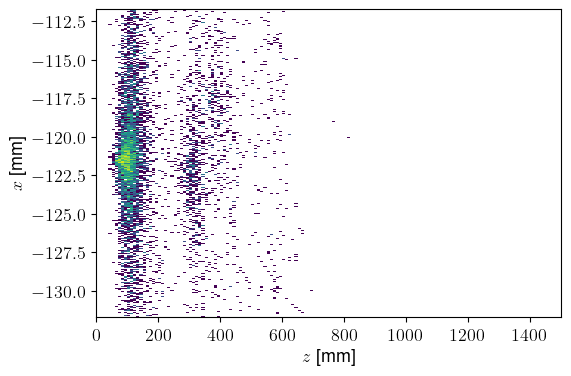

In [62]:
event_id = 0
event_df = df.query(f"event_id == {event_id}")
event_truth = truth_df.query(f"event_id == {event_id}")
truth = get_truth_particle(event_truth)
plot_zx_hist(event_df, truth, geo=mosiax_geo, range=10)

In [ ]:
event_id = 0
event_df = df.query(f"event_id == {event_id}")
event_truth = truth.query(f"event_id == {event_id}")
event_truth

AttributeError: 'TruthParticle' object has no attribute 'query'

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x1722b0980>, cbar=None, text=[])

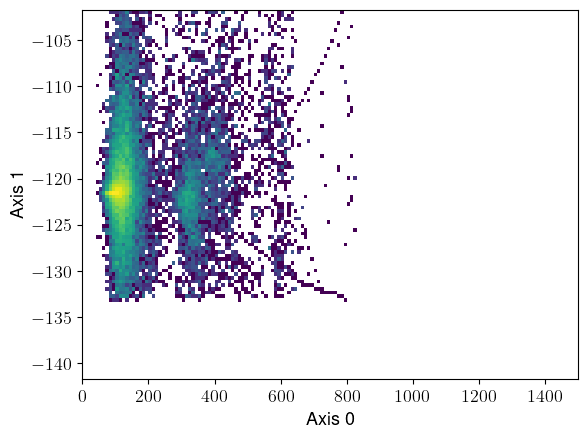

In [29]:
event_id = 0
event_df = df.query(f"event_id == {event_id}")
event_truth = truth.query(f"event_id == {event_id}").iloc[0]
plot_range = 20

truth_x, truth_y = event_truth[["vx", "vy"]]

fig, ax = plt.subplots()
h = hist.Hist(
    hist.axis.Regular(150, 0, 1500),
    hist.axis.Regular(100, truth_x - plot_range, truth_x + plot_range),
)
h.fill(event_df["z"], event_df["x"])
mplhep.hist2dplot(
    h, cmap="viridis", norm=mpl.colors.LogNorm(), cbar=False, ax=ax, flow=False
)

In [ ]:
truth_x, truth_y = event_truth[["vx", "vy"]]

In [24]:
truth_x

-121.72957984768132

In [ ]:
geo.